# Project 1 — Regression, resampling methods and gradient descent

**FYS-STK3155/4155**, University of Oslo, autumn 2026
**Parisa Amin**

We study polynomial regression on Runge's function

$$f(x) = \frac{1}{1+25x^2}, \qquad x \in [-1, 1],$$

with ordinary least squares, Ridge and Lasso; the bootstrap and $k$-fold
cross-validation; and gradient-descent optimisers.

Reusable functions live in `regression.py`; this notebook runs the experiments.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# pick up edits to regression.py without restarting the kernel
%load_ext autoreload
%autoreload 2

from regression import (runge, make_data, polynomial_features, MSE, R2, ols, fit_predict,
                        BLUE, RED, YELLOW, GREY, GREEN)

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
# Part a) Ordinary Least Squares

**Goal:** build the machinery, and see overfitting happen — training MSE falling
for ever while test MSE turns back up, driven by coefficients that explode.

## a.1 The data

Generate Runge data on $[-1,1]$ with noise $\varepsilon\sim\mathcal{N}(0,\sigma^2)$,
$\sigma = 0.1$. Plot the noisy samples against the true function to check it looks right.

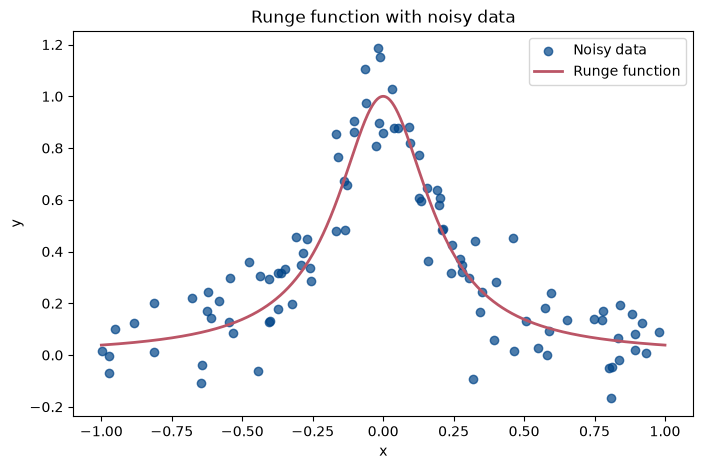

In [43]:
x , y= make_data(n= 100 , sigma= 0.1 , seed= 2026)
x_fine = np.linspace(-1,1, 1000)
y_fine = runge(x_fine)


plt.figure(figsize=(8,5))
plt.scatter(x,y, label= "Noisy data" , color= BLUE , alpha= 0.7)
plt.plot(x_fine , y_fine , label= "Runge function" , color= RED , linewidth= 2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge function with noisy data")
plt.legend()

plt.show()


## a.2 Train/test split and scaling

Split roughly 80/20. Then **centre `y` and standardise the feature columns —
fitting the scaler on the training data only**, and applying those same numbers to
the test data.

Why it matters: if the scaler sees the test set, information has leaked from test
into train and your error estimate is optimistically biased. The project asks for a
critical discussion of this, so write down what you did and why.

In [44]:
from sklearn.model_selection import train_test_split

x_train , x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2 , random_state= 2026)

print(len(x_test))
print(len(x_train))


20
80


## a.3 MSE and $R^2$ against polynomial degree

For degree $= 1 \ldots 15$: build the design matrix, fit OLS, record training and
test MSE and $R^2$.

Expect: training MSE falls monotonically; test MSE falls then rises. Use a log
scale on the MSE axis and mark the noise floor $\sigma^2$ with a grey dashed line —
no model can do better than that.

In [45]:
print(x_train.shape)
print(x_train.ndim)

(80,)
1


In [46]:

# x = raw input vector, X = polynomial design matrix
degrees = np.arange(1, 16)

#print(degrees)

mse_train= np.zeros(len(degrees))
mse_test= np.zeros(len(degrees))

r2_train= np.zeros(len(degrees))
r2_test= np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)
    X_test= polynomial_features(x_test, degree)

    X_mean= np.mean(X_train, axis=0)  #capital X
    X_std= np.std(X_train, axis=0)    #capital X

    X_train_scaled= (X_train - X_mean)/X_std
    X_test_scaled= (X_test - X_mean)/ X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta= ols(X_train_scaled, y_train_centered)

    y_train_pred = X_train_scaled @ theta + y_mean
    y_test_pred = X_test_scaled @ theta + y_mean


    mse_train[i]= MSE(y_train, y_train_pred)
    mse_test[i]= MSE(y_test, y_test_pred)

    r2_train[i]= R2(y_train, y_train_pred)
    r2_test[i]= R2(y_test, y_test_pred) 

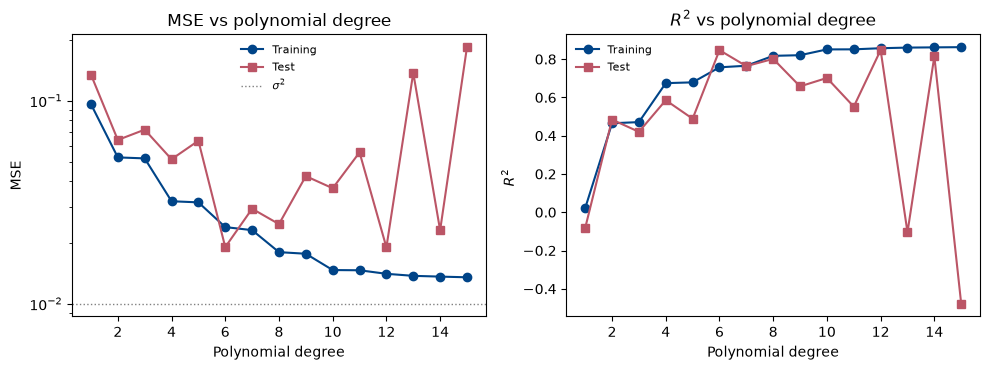

In [47]:
plt.figure(figsize=(10, 3.8))

#MSE plot
plt.subplot(1, 2, 1)

plt.plot(degrees, mse_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, mse_test, "s-",color=RED, label="Test")

plt.yscale("log")                                      # MSE panel only
plt.axhline(0.1**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("MSE vs polynomial degree")
plt.legend(frameon=False, fontsize=8)

#R2 plot
plt.subplot(1, 2, 2)

plt.plot(degrees, r2_train,"o-", color=BLUE, label="Training")
plt.plot(degrees, r2_test,"s-", color=RED, label="Test")

plt.xlabel("Polynomial degree")
plt.ylabel( r"$R^2$ " )
plt.title( r"$R^2$ vs polynomial degree")
plt.legend(frameon=False, fontsize=8)


plt.tight_layout()
plt.savefig("../results/a3_mse_r2.pdf", bbox_inches="tight")
plt.show()


## a.4 The coefficients $\theta$ against degree

This is the figure that explains the U-shape. Plot the magnitude of the fitted
coefficients as the degree grows — expect them to reach enormous values with
alternating signs, because the design matrix becomes nearly singular and the fit
relies on huge cancelling terms.

A log scale on $|\theta_j|$ makes it readable.

In [48]:
 # a.4 — how the coefficients grow with degree

theta_all = []
max_theta = np.zeros(len(degrees))

for i, degree in enumerate(degrees):

    X_train= polynomial_features(x_train, degree)

    X_mean= np.mean(X_train, axis=0)
    X_std = np.std(X_train, axis=0)

    X_train_scaled= (X_train - X_mean) / X_std

    y_mean= np.mean(y_train)
    y_train_centered= y_train - y_mean

    theta = ols(X_train_scaled, y_train_centered)
    theta_all.append(theta)

    max_theta[i] = np.max(np.abs(theta))



In [49]:
#print(max_theta)
print(theta_all[5])

print(max_theta[5])

[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]
2.1178573485608494


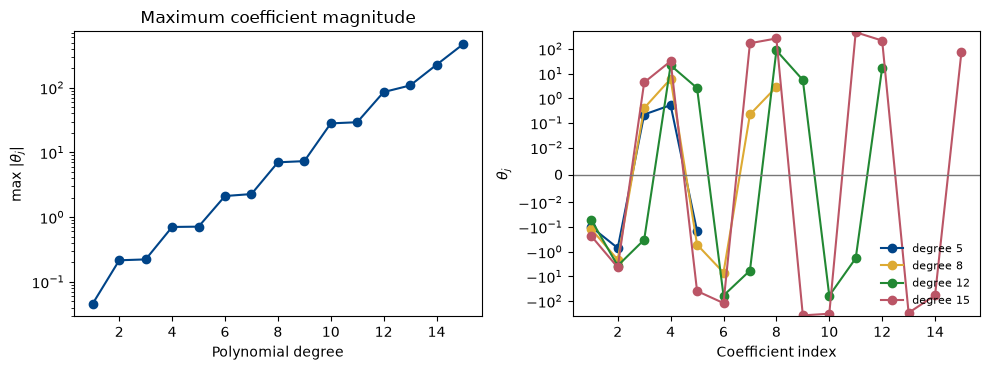

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))


##Left panel

axes[0].semilogy(degrees, max_theta, "o-", color=BLUE )

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel(r"max $|\theta_j|$")
axes[0].set_title("Maximum coefficient magnitude")


## Right panel
for degree, c in zip([5, 8, 12, 15], [BLUE, YELLOW, GREEN, RED]):
    theta = theta_all[degree - 1]
    j = np.arange(1, degree + 1)
    axes[1].plot(j, theta, "o-", color=c, label=f"degree {degree}")



axes[1].axhline(0, color=GREY, linewidth=1)
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel(r"$\theta_j$")
axes[1].legend(frameon= False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/a4_theta.pdf", bbox_inches="tight")
plt.show()




## a.5 Dependence on the number of points and the noise level

Repeat the degree sweep for a few values of $n$ and of $\sigma$.

Expect: more data supports a higher degree before overfitting sets in; more noise
pushes the optimal degree down.

In [51]:
# Different number of points
degrees = np.arange(1, 16)
n_values = [50, 100, 200, 1000]
sigma_fixed= 0.1

mse_by_n= {}


for n in n_values:

    #Generate new data set
    x_n , y_n = make_data(n=n, sigma=sigma_fixed, seed=2026)

    #split and test
    x_train_n, x_test_n, y_train_n , y_test_n = train_test_split(x_n, y_n, test_size= 0.2, random_state=2026)

     # One MSE value for each degree
    mse_test_n = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_n, x_test_n, y_train_n, degree)

        mse_test_n[i] = MSE(y_test_n, y_test_pred)


    mse_by_n[n] = mse_test_n



In [52]:
sigma_values = [0.01, 0.1, 0.3]
n_fixed = 100

mse_by_sigma = {}

for sigma in sigma_values:
    #Generate new data set
    x_s , y_s = make_data(n=n_fixed, sigma=sigma, seed=2026)

    #split and test
    x_train_s, x_test_s, y_train_s , y_test_s = train_test_split(x_s, y_s, test_size= 0.2, random_state=2026)


    # Store test MSE for all degrees
    mse_test_s = np.zeros(len(degrees))

    for i , degree in enumerate(degrees):
        y_train_pred , y_test_pred , theta = fit_predict(x_train_s, x_test_s, y_train_s, degree)

        mse_test_s[i] = MSE(y_test_s, y_test_pred)


    mse_by_sigma[sigma] = mse_test_s

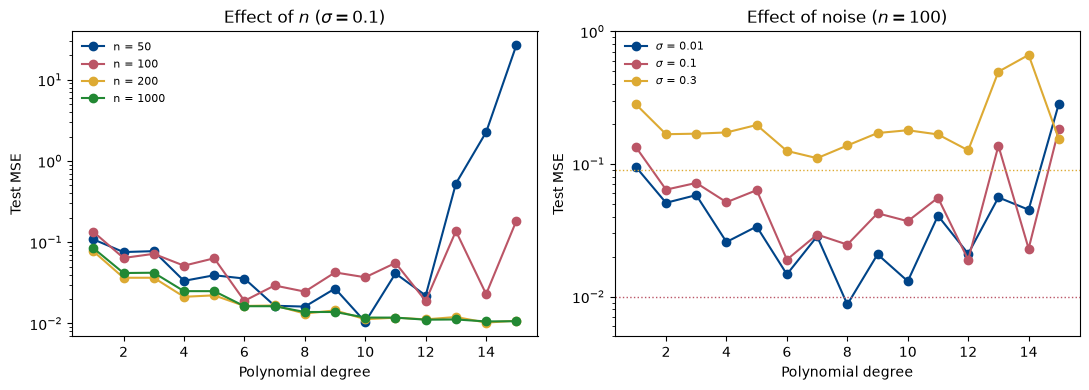

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = [BLUE, RED, YELLOW, GREEN]

  
# --------------------------------------------------
# Left panel: different n
# --------------------------------------------------

for i, n in enumerate(n_values):

      axes[0].semilogy(degrees, mse_by_n[n], "o-", color=colors[i], label=f"n = {n}")

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("Test MSE")
axes[0].set_title(r"Effect of $n$ ($\sigma=0.1$)")
axes[0].legend(frameon=False, fontsize=8)


# --------------------------------------------------
# Right panel: different sigma
# --------------------------------------------------

for i, sigma in enumerate(sigma_values):

    axes[1].semilogy(degrees, mse_by_sigma[sigma], "o-", color=colors[i], label=fr"$\sigma$ = {sigma}")
  
    axes[1].axhline(sigma**2, color=colors[i], linestyle=":", linewidth=1)
  
axes[1].set_ylim(5e-3, 1)
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("Test MSE")
axes[1].set_title(r"Effect of noise ($n=100$)")
axes[1].legend(frameon=False, fontsize=8)

 
plt.tight_layout()
plt.savefig("../results/a5_n_sigma.pdf", bbox_inches="tight")
plt.show()
  


---
# Part b) Ridge regression

**Goal:** control the explosion. Ridge minimises

$$C(\theta) = \frac{1}{n}\lVert X\theta - y \rVert^2 + \lambda\lVert\theta\rVert^2,
\qquad
\theta = (X^TX + n\lambda I)^{-1}X^Ty.$$

**The factor $n$ comes from the $1/n$ in the cost function — don't drop it.**

## b.1 Implement Ridge, and benchmark it

Add `ridge(X, y, lam)` to `regression.py`, then check it two ways:

1. `lam = 0` must reproduce your OLS result exactly
2. it must match `Ridge(alpha=n*lam, fit_intercept=False)` from scikit-learn

These benchmarks belong in the report — the course guidelines call validation
against known results *"extremely important"*.

In [54]:
import regression
import importlib
importlib.reload(regression)

from regression import ridge

In [55]:
from sklearn.linear_model import Ridge

In [56]:
theta_ols = ols(X_train_scaled, y_train_centered)
theta_ridge0= ridge(X_train_scaled, y_train_centered, 0)

print("max |OLS - Ridge(lambda=0)| =", np.max(np.abs(theta_ols - theta_ridge0 )))

print(np.allclose(theta_ols, theta_ridge0))


max |OLS - Ridge(lambda=0)| = 0.00017438766707300601
True


## b.1 Our Ridge vs scikit-learn Ridge

In [57]:
theta_ours = ridge( X_train_scaled, y_train_centered, lam = 0.01)

In [58]:
n= X_train_scaled.shape[0]

lam= 0.01
model_Ridge= Ridge(alpha= n*lam , fit_intercept= False)
model_Ridge.fit(X_train_scaled, y_train_centered)
theta_sklearn = model_Ridge.coef_

print("max |sklearnRidge - OurRidge| =", np.max(np.abs(theta_sklearn - theta_ours )))
print(np.allclose(theta_sklearn, theta_ours))

max |sklearnRidge - OurRidge| = 3.83026943495679e-15
True


## b.2 MSE against $\lambda$, at fixed degree

In [59]:
lambdas =np.logspace(-8, 2, 9)
print(lambdas)

[  0.       0.       0.       0.0001   0.001    0.0178   0.3162   5.6234
 100.    ]


In [60]:
degree= 15
mse_ridge= np.zeros(len(lambdas))
r2_ridge= np.zeros(len(lambdas))
theta_ridge_all= []

for i, lam in enumerate(lambdas):

   y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, degree, lam)


   mse_ridge[i]= MSE(y_test, y_test_pred)
   r2_ridge[i]= R2(y_test, y_test_pred)
   theta_ridge_all.append(theta)

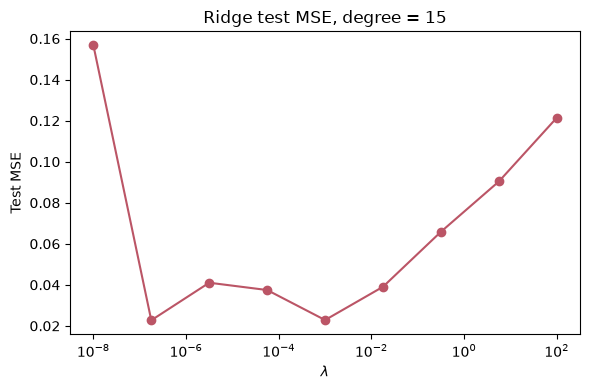

In [61]:
plt.figure(figsize=(6, 4))

plt.semilogx( lambdas,mse_ridge, "o-", color=RED)

plt.xlabel(r"$\lambda$")
plt.ylabel("Test MSE")
plt.title(f"Ridge test MSE, degree = {degree}")

plt.tight_layout()
plt.show()

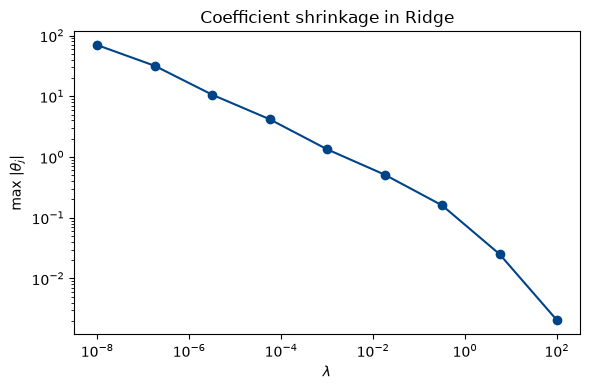

In [62]:
max_theta_ridge= np.zeros(len(lambdas))

for i, theta in enumerate(theta_ridge_all):
    max_theta_ridge[i]= np.max(np.abs(theta_ridge_all[i]))

plt.figure(figsize=(6, 4))
plt.loglog(lambdas, max_theta_ridge, "o-",color=BLUE
)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"max $|\theta_j|$")
plt.title("Coefficient shrinkage in Ridge")

plt.tight_layout()
plt.show()


In [63]:
# comparing OLS and Ridge

y_train_pred_ols , y_test_pred_ols, theta_ols= fit_predict(x_train, x_test, y_train, degree, lam=0.0)

y_train_pred_ridge, y_test_pred_ridge, theta_ridge= fit_predict(x_train, x_test, y_train, degree, lam= 0.01)

print(f"OLS: MSE = {MSE(y_test, y_test_pred_ols)}, R2 = {R2(y_test, y_test_pred_ols)}")
print(f"Ridge: MSE = {MSE(y_test, y_test_pred_ridge)}, R2 = {R2(y_test, y_test_pred_ridge)}")

print("OLS max |theta|   :", np.max(np.abs(theta_ols)))
print("Ridge max |theta| :", np.max(np.abs(theta_ridge)))

OLS: MSE = 0.18336464980949974, R2 = -0.47775866835032765
Ridge: MSE = 0.033849746768931384, R2 = 0.7272006531181436
OLS max |theta|   : 469.21920913108863
Ridge max |theta| : 0.6046401694155348


## b.3 MSE against degree, for several $\lambda$

In [67]:
lambdas_sweep = [0.0, 1e-6, 1e-4, 1e-2, 1.0]
mse_by_lambda = {}


for lam in lambdas_sweep:

    mse_deg= np.zeros(len(degrees))
    for i , deg in enumerate(degrees):
        y_train_pred, y_test_pred, theta= fit_predict(x_train, x_test, y_train, deg, lam=lam)
        mse_deg[i]= MSE(y_test, y_test_pred)

    mse_by_lambda[lam]= mse_deg



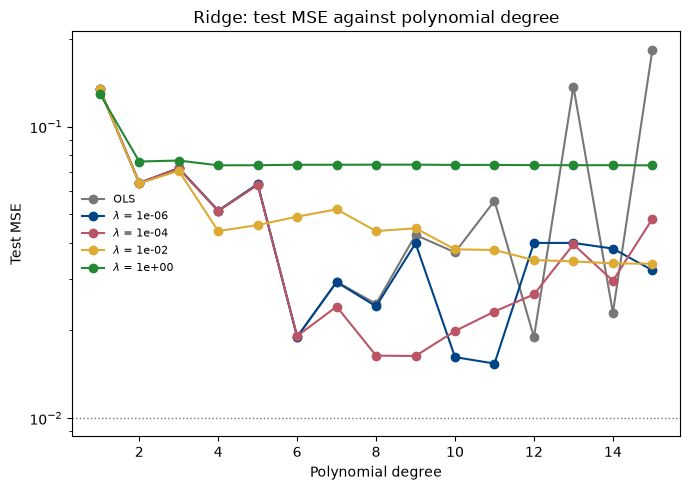

In [68]:
colors_b3 = [GREY, BLUE, RED, YELLOW, GREEN]
  
plt.figure(figsize=(7, 5))

for i, lam in enumerate(lambdas_sweep):
 
    label = "OLS" if lam == 0.0 else fr"$\lambda$ = {lam:.0e}"

    plt.semilogy(degrees, mse_by_lambda[lam], "o-", color=colors_b3[i], label=label)
  

plt.axhline(0.1**2, color=GREY, linestyle=":", linewidth=1)
  
plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.title("Ridge: test MSE against polynomial degree")
plt.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/b3_mse_degree.pdf", bbox_inches="tight")
plt.show()

## b.4 Coefficient paths

Plot $\theta_j$ against $\lambda$ (log axis). Watch every coefficient shrink smoothly
toward zero — but **never reach it exactly**. That is the difference from Lasso in
part g).

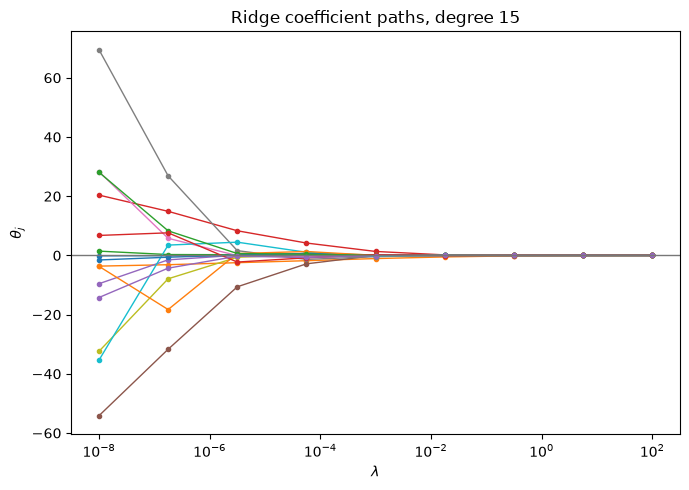

In [69]:
theta_paths = np.array(theta_ridge_all)

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas, theta_paths[:, j], "o-", linewidth=1, markersize=3)
 

plt.axhline(0, color=GREY, linewidth=1)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")
 
plt.tight_layout()
plt.savefig("../results/b4_coef_paths.pdf", bbox_inches="tight")
plt.show()
  


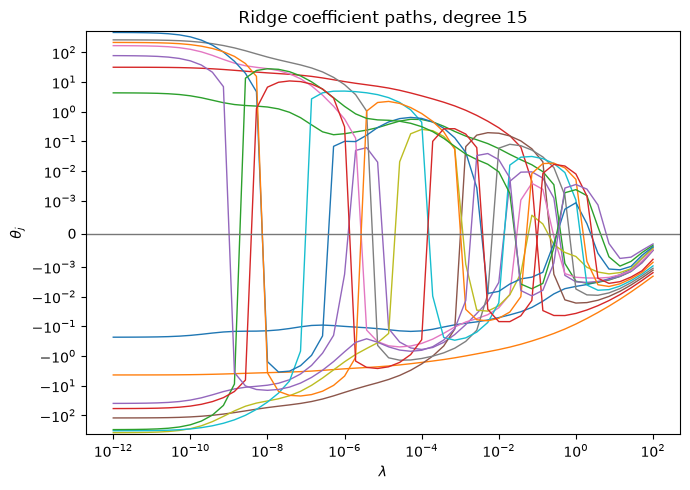

smallest |theta| at lam = 100: 0.0003029802222823352
any coefficient exactly zero: False


In [70]:
lambdas_paths = np.logspace(-12, 2, 50)

theta_paths = np.array([fit_predict(x_train, x_test, y_train, 15, lam=lam)[2]
                          for lam in lambdas_paths])

plt.figure(figsize=(7, 5))

for j in range(theta_paths.shape[1]):
      plt.semilogx(lambdas_paths, theta_paths[:, j], "-", linewidth=1)

plt.axhline(0, color=GREY, linewidth=1)
plt.yscale("symlog", linthresh=1e-3)

plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\theta_j$")
plt.title("Ridge coefficient paths, degree 15")

plt.tight_layout()
plt.savefig("../results/b4_coef_paths.pdf", bbox_inches="tight")
plt.show()

print("smallest |theta| at lam = 100:", np.min(np.abs(theta_paths[-1])))
print("any coefficient exactly zero:", np.any(theta_paths == 0))



## b.5 The SVD picture

With $X = U\Sigma V^T$, the two estimators differ only by a factor on each singular
direction:

| | coefficient on direction $j$ |
|---|---|
| OLS | $\dfrac{1}{\sigma_j}(u_j^Ty)$ |
| Ridge | $\dfrac{\sigma_j}{\sigma_j^2+\lambda}(u_j^Ty)$ |

so Ridge applies the shrinkage factor $\sigma_j^2/(\sigma_j^2+\lambda)$: directions with
large $\sigma_j$ pass through untouched, directions with small $\sigma_j$ are crushed.

Compute the singular values of your degree-15 design matrix, plot the shrinkage
factor for a few $\lambda$, and connect it to the coefficient explosion in a.4.

In [71]:
degree = 15

# Degree-15 design matrix
X_train = polynomial_features(x_train, degree)


X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std


singular_values = np.linalg.svd(X_train_scaled, compute_uv=False)

print("Singular values:")
print(singular_values)

print("\nLargest singular value :", singular_values[0])
print("Smallest singular value:", singular_values[-1])
print("Condition number       :", singular_values[0] / singular_values[-1])

Singular values:
[27.5911 18.0132  8.3101  5.9052  2.733   1.5002  0.705   0.3054  0.1289
  0.0461  0.0199  0.0053  0.0022  0.0004  0.0001]

Largest singular value : 27.591074964720246
Smallest singular value: 0.00014874894523636388
Condition number       : 185487.53351412134


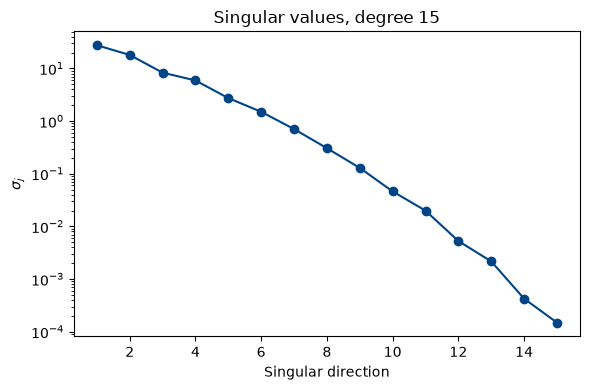

In [84]:
plt.figure(figsize=(6, 4))

plt.semilogy(
    np.arange(1, len(singular_values) + 1),
    singular_values,
    "o-",
    color=BLUE
)

plt.xlabel("Singular direction")
plt.ylabel(r"$\sigma_j$")
plt.title("Singular values, degree 15")
plt.savefig("../results/b5_singular_values.pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()

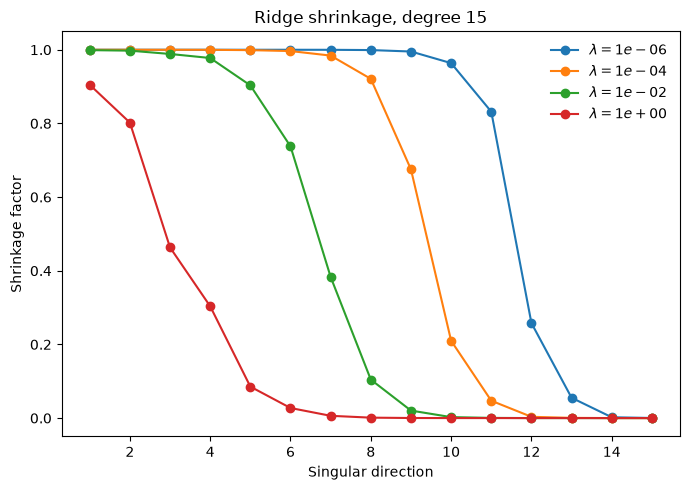

In [85]:
lambdas_svd = [1e-6, 1e-4, 1e-2, 1.0]

n_train = X_train_scaled.shape[0]

plt.figure(figsize=(7, 5))

for lam in lambdas_svd:

    shrinkage = singular_values**2 / (
        singular_values**2 + n_train * lam
    )

    plt.plot(
        np.arange(1, len(singular_values) + 1),
        shrinkage,
        "o-",
        label=fr"$\lambda={lam:.0e}$"
    )

plt.xlabel("Singular direction")
plt.ylabel("Shrinkage factor")
plt.title("Ridge shrinkage, degree 15")
plt.ylim(-0.05, 1.05)
plt.legend(frameon=False)
plt.savefig("../results/b5_shrinkage.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [86]:
print("\nShrinkage of smallest singular direction:")

for lam in lambdas_svd:

    shrinkage = singular_values**2 / (
        singular_values**2 + n_train * lam
    )

    print(
        f"lambda = {lam:.0e}  "
        f"largest direction = {shrinkage[0]:.6f}  "
        f"smallest direction = {shrinkage[-1]:.6e}"
    )


Shrinkage of smallest singular direction:
lambda = 1e-06  largest direction = 1.000000  smallest direction = 2.765016e-04
lambda = 1e-04  largest direction = 0.999989  smallest direction = 2.765773e-06
lambda = 1e-02  largest direction = 0.998950  smallest direction = 2.765781e-08
lambda = 1e+00  largest direction = 0.904905  smallest direction = 2.765781e-10


---
# Part c) Bias-variance tradeoff and the bootstrap

## c.1 Train/test MSE against complexity

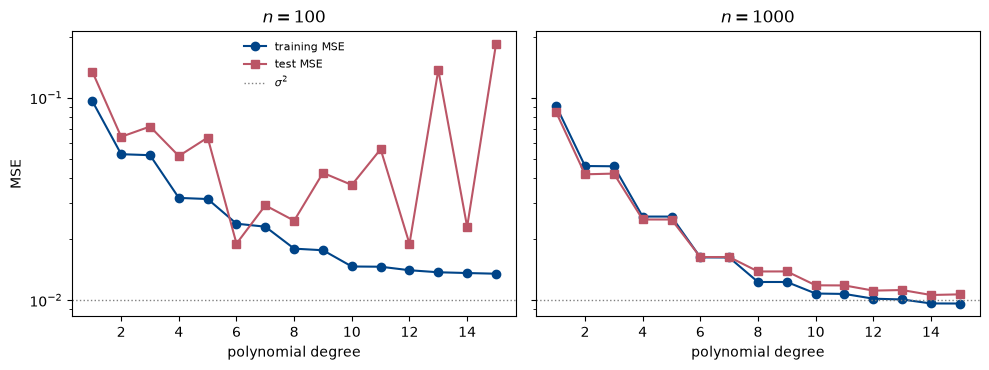

In [78]:
degrees_c = np.arange(1, 16)
sigma = 0.1

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)

for ax, n in zip(axes, (100, 1000)):
    x_n, y_n = make_data(n=n, sigma=sigma, seed=2026)
    x_tr, x_te, y_tr, y_te = train_test_split(x_n, y_n, test_size=0.2, random_state=2026)

    mse_train = np.zeros(len(degrees_c))
    mse_test = np.zeros(len(degrees_c))

    for i, degree in enumerate(degrees_c):
        y_train_pred, y_test_pred, theta = fit_predict(x_tr, x_te, y_tr, degree)
        mse_train[i] = MSE(y_tr, y_train_pred)
        mse_test[i] = MSE(y_te, y_test_pred)

    ax.plot(degrees_c, mse_train, "o-", color=BLUE, label="training MSE")
    ax.plot(degrees_c, mse_test, "s-", color=RED, label="test MSE")
    ax.axhline(sigma**2, color="gray", ls=":", lw=1, label=r"$\sigma^2$")
    ax.set_yscale("log")
    ax.set_xlabel("polynomial degree")
    ax.set_title(f"$n = {n}$")

axes[0].set_ylabel("MSE")
axes[0].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/c1_train_test_mse.pdf", bbox_inches="tight")
plt.show()

## c.2 Bootstrap: bias-variance against degree

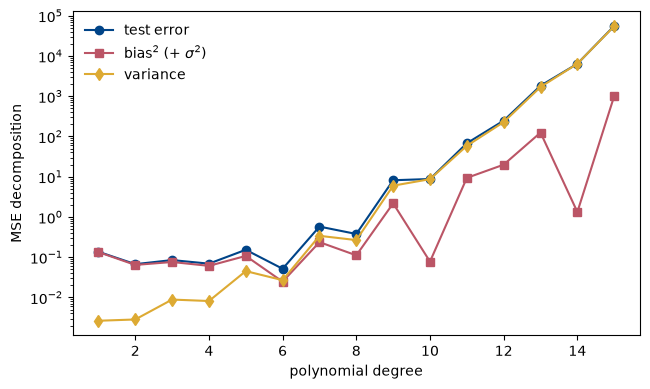

In [79]:
from sklearn.utils import resample


def bias_variance_sweep(n=100, sigma=0.1, degrees=degrees_c, n_bootstraps=100, seed=2026):
    x, y = make_data(n=n, sigma=sigma, seed=seed)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)
    y_test_col = y_test.reshape(-1, 1)

    error, bias, variance = (np.zeros(len(degrees)) for _ in range(3))

    for i, degree in enumerate(degrees):
        y_pred = np.empty((y_test.shape[0], n_bootstraps))

        for b in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train, random_state=seed + b)
            y_pred[:, b] = fit_predict(x_, x_test, y_, degree)[1]

        error[i] = np.mean(np.mean((y_test_col - y_pred)**2, axis=1, keepdims=True))
        bias[i] = np.mean((y_test_col - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[i] = np.mean(np.var(y_pred, axis=1, keepdims=True))

    return error, bias, variance


error, bias, variance = bias_variance_sweep(n=100)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(degrees_c, error, "o-", color=BLUE, label="test error")
ax.plot(degrees_c, bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(degrees_c, variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("../results/c2_bias_variance.pdf", bbox_inches="tight")
plt.show()

## c.3 Dependence on the number of data points

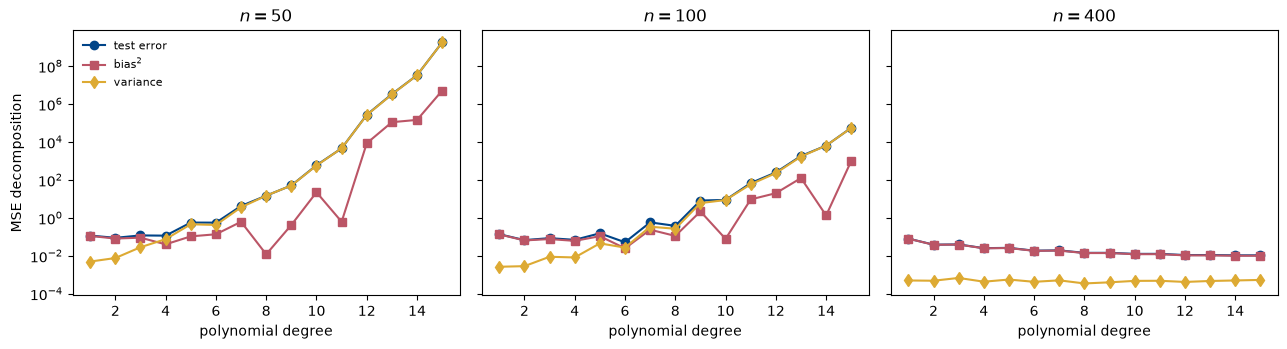

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)

for ax, n in zip(axes, (50, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n)

    ax.plot(degrees_c, err, "o-", color=BLUE, label="test error")
    ax.plot(degrees_c, b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(degrees_c, var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_xlabel("polynomial degree")
    ax.set_title(f"$n = {n}$")

axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("../results/c3_bias_variance_n.pdf", bbox_inches="tight")
plt.show()

---
# Part d) Cross-validation

---
# Part e) Gradient descent, analytical and automatic gradients

## e.1 The analytical gradient

In [81]:

degree_e = 6

X_train_e = polynomial_features(x_train, degree_e)
X_test_e = polynomial_features(x_test, degree_e)


X_mean_e = X_train_e.mean(axis=0)
X_std_e = X_train_e.std(axis=0)

X_train_e = (X_train_e - X_mean_e) / X_std_e
X_test_e = (X_test_e - X_mean_e) / X_std_e

# Centre target using training mean
y_mean_e = y_train.mean()
y_train_e = y_train - y_mean_e


def gradient_ols(theta, X, y):
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y)


def gradient_ridge(theta, X, y, lam):
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

In [82]:
theta_test = np.zeros(degree_e)

g_ols = gradient_ols(theta_test, X_train_e, y_train_e)
g_ridge = gradient_ridge(
    theta_test,
    X_train_e,
    y_train_e,
    lam=0.01
)

print("OLS gradient shape:  ", g_ols.shape)
print("Ridge gradient shape:", g_ridge.shape)

print("OLS gradient:")
print(g_ols)

print("\nRidge gradient:")
print(g_ridge)

OLS gradient shape:   (6,)
Ridge gradient shape: (6,)
OLS gradient:
[0.0923 0.4272 0.1109 0.3302 0.1131 0.2767]

Ridge gradient:
[0.0923 0.4272 0.1109 0.3302 0.1131 0.2767]


In [83]:
theta_test = np.ones(degree_e)

g_ols = gradient_ols(theta_test, X_train_e, y_train_e)
g_ridge = gradient_ridge(
    theta_test,
    X_train_e,
    y_train_e,
    lam=0.01
)

print("OLS gradient:")
print(g_ols)

print("\nRidge gradient:")
print(g_ridge)

print("\nRidge - OLS:")
print(g_ridge - g_ols)

OLS gradient:
[7.1037 7.9856 8.0014 8.2907 7.9211 8.1315]

Ridge gradient:
[7.1237 8.0056 8.0214 8.3107 7.9411 8.1515]

Ridge - OLS:
[0.02 0.02 0.02 0.02 0.02 0.02]


## e.2 Automatic differentiation with JAX

In [88]:
import jax
import jax.numpy as jnp


jax.config.update("jax_enable_x64", True)


def cost_ols_jax(theta, X, y):
    return jnp.mean((X @ theta - y)**2)


# Ridge cost
def cost_ridge_jax(theta, X, y, lam):
    return jnp.mean((X @ theta - y)**2) + lam * jnp.sum(theta**2)


gradient_ols_ad = jax.grad(cost_ols_jax, argnums=0)

gradient_ridge_ad = jax.grad(cost_ridge_jax, argnums=0)

In [90]:

Xj = jnp.asarray(X_train_e)
yj = jnp.asarray(y_train_e)


theta_check = np.linspace(
    0.1,
    1.0,
    X_train_e.shape[1]
)

lam_check = 0.01


# ---------- OLS ----------

g_ols_analytic = gradient_ols(
    theta_check,
    X_train_e,
    y_train_e
)

g_ols_ad = gradient_ols_ad(
    jnp.asarray(theta_check),
    Xj,
    yj
)


# ---------- Ridge ----------

g_ridge_analytic = gradient_ridge(
    theta_check,
    X_train_e,
    y_train_e,
    lam_check
)

g_ridge_ad = gradient_ridge_ad(
    jnp.asarray(theta_check),
    Xj,
    yj,
    lam_check
)


print(
    "OLS max |analytic - AD| =",
    np.max(np.abs(g_ols_analytic - np.asarray(g_ols_ad)))
)

print(
    "Ridge max |analytic - AD| =",
    np.max(np.abs(g_ridge_analytic - np.asarray(g_ridge_ad)))
)

OLS max |analytic - AD| = 8.881784197001252e-16
Ridge max |analytic - AD| = 8.881784197001252e-16


## e.3 Plain gradient descent for OLS

In [91]:
theta_ols_closed = ols(
    X_train_e,
    y_train_e
)

print("Closed-form theta:")
print(theta_ols_closed)

Closed-form theta:
[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]


In [92]:
def gradient_descent(theta0, gradient_function, eta,
                     max_iter=20000, tol=1e-10):

    theta = theta0.copy()

    cost_history = []

    for k in range(max_iter):

       
        gradient = np.asarray(
            gradient_function(theta)
        )

      
        theta = theta - eta * gradient

      
        cost = np.mean(
            (X_train_e @ theta - y_train_e)**2
        )

        cost_history.append(cost)

        
        if np.linalg.norm(gradient) < tol:
            break

    return theta, np.array(cost_history), k + 1

In [93]:
n_train = len(y_train_e)

H_ols = (
    2.0 / n_train
) * X_train_e.T @ X_train_e

lambda_max = np.linalg.eigvalsh(H_ols).max()

eta_max = 2.0 / lambda_max


eta = 0.5 * eta_max

print("lambda_max =", lambda_max)
print("eta_max     =", eta_max)
print("eta used    =", eta)

lambda_max = 7.696475114645242
eta_max     = 0.2598592173960647
eta used    = 0.12992960869803236


In [94]:
# Initial parameters
theta0 = np.zeros(X_train_e.shape[1])


# Analytical gradient function for the current training data
def ols_gradient_analytic(theta):
    return gradient_ols(
        theta,
        X_train_e,
        y_train_e
    )


# Run gradient descent
theta_gd_analytic, cost_analytic, n_iter_analytic = gradient_descent(
    theta0=theta0,
    gradient_function=ols_gradient_analytic,
    eta=eta,
    max_iter=20000,
    tol=1e-10
)


print("Analytical-gradient GD finished.")
print("Number of iterations:", n_iter_analytic)
print("Theta:")
print(theta_gd_analytic)

Analytical-gradient GD finished.
Number of iterations: 20000
Theta:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]


In [95]:

Xj = jnp.asarray(X_train_e)
yj = jnp.asarray(y_train_e)


def ols_gradient_ad(theta):

    theta_jax = jnp.asarray(theta)

    g = gradient_ols_ad(
        theta_jax,
        Xj,
        yj
    )

    
    return np.asarray(g)


theta_gd_ad, cost_ad, n_iter_ad = gradient_descent(
    theta0=theta0,
    gradient_function=ols_gradient_ad,
    eta=eta,
    max_iter=20000,
    tol=1e-10
)


print("\nJAX-gradient GD finished.")
print("Number of iterations:", n_iter_ad)
print("Theta:")
print(theta_gd_ad)


JAX-gradient GD finished.
Number of iterations: 20000
Theta:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]


In [104]:

theta_ols_closed = ols(
    X_train_e,
    y_train_e
)


theta_ols_closed = np.asarray(theta_ols_closed).ravel()
theta_gd_analytic = np.asarray(theta_gd_analytic).ravel()
theta_gd_ad = np.asarray(theta_gd_ad).ravel()


error_analytic = np.linalg.norm(
    theta_gd_analytic - theta_ols_closed
)

error_ad = np.linalg.norm(
    theta_gd_ad - theta_ols_closed
)

error_between_gd = np.linalg.norm(
    theta_gd_analytic - theta_gd_ad
)


print("\n--------------------------------------")
print("Comparison with closed-form OLS")
print("--------------------------------------")

print("Closed-form theta:")
print(theta_ols_closed)

print("\nGD theta — analytical gradient:")
print(theta_gd_analytic)

print("\nGD theta — JAX gradient:")
print(theta_gd_ad)

print("\nIterations:")
print("Analytical gradient:", n_iter_analytic)
print("JAX gradient       :", n_iter_ad)

print("\nParameter errors:")
print(
    "||theta_GD analytical - theta_closed|| =",
    error_analytic
)

print(
    "||theta_GD JAX - theta_closed||        =",
    error_ad
)

print(
    "||theta_GD analytical - theta_GD JAX|| =",
    error_between_gd
)


--------------------------------------
Comparison with closed-form OLS
--------------------------------------
Closed-form theta:
[-0.0534 -1.3045  0.0159  2.1179  0.0137 -1.0449]

GD theta — analytical gradient:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]

GD theta — JAX gradient:
[-0.0535 -1.3044  0.0159  2.1177  0.0137 -1.0448]

Iterations:
Analytical gradient: 20000
JAX gradient       : 20000

Parameter errors:
||theta_GD analytical - theta_closed|| = 0.00018120458647552303
||theta_GD JAX - theta_closed||        = 0.00018120458647992926
||theta_GD analytical - theta_GD JAX|| = 4.454686121614751e-15


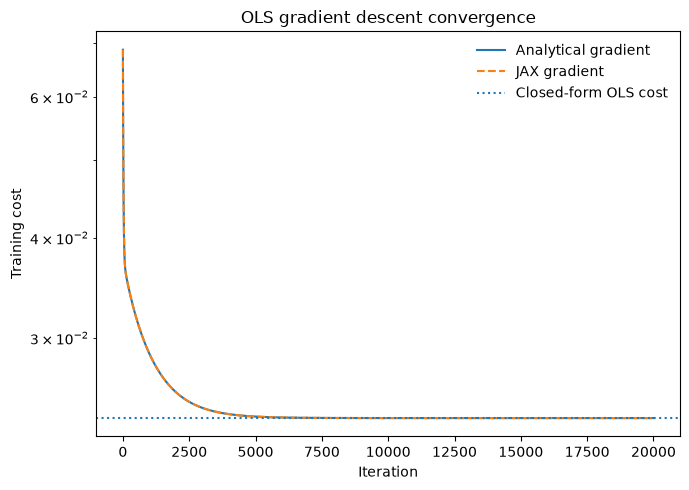

In [105]:


closed_cost = np.mean(
    (X_train_e @ theta_ols_closed - y_train_e)**2
)


plt.figure(figsize=(7, 5))

plt.semilogy(
    np.arange(1, len(cost_analytic) + 1),
    cost_analytic,
    label="Analytical gradient"
)

plt.semilogy(
    np.arange(1, len(cost_ad) + 1),
    cost_ad,
    "--",
    label="JAX gradient"
)

plt.axhline(
    closed_cost,
    linestyle=":",
    label="Closed-form OLS cost"
)

plt.xlabel("Iteration")
plt.ylabel("Training cost")
plt.title("OLS gradient descent convergence")
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("../results/e3_gd_convergence.pdf", bbox_inches="tight")
plt.show()

In [106]:
x_plot = np.linspace(-1, 1, 500)

X_plot = polynomial_features(
    x_plot,
    degree_e
)


X_plot_e = (
    X_plot - X_mean_e
) / X_std_e

In [107]:

y_plot_closed = (
    X_plot_e @ theta_ols_closed
    + y_mean_e
)

# GD with analytical gradient
y_plot_gd_analytic = (
    X_plot_e @ theta_gd_analytic
    + y_mean_e
)

# GD with JAX gradient
y_plot_gd_ad = (
    X_plot_e @ theta_gd_ad
    + y_mean_e
)

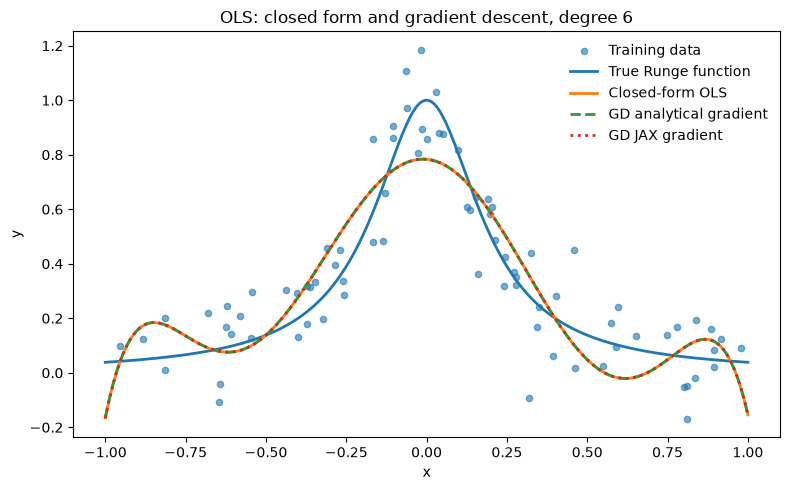

In [108]:
plt.figure(figsize=(8, 5))

plt.scatter(
    x_train,
    y_train,
    s=20,
    alpha=0.6,
    label="Training data"
)

plt.plot(
    x_plot,
    runge(x_plot),
    linewidth=2,
    label="True Runge function"
)

plt.plot(
    x_plot,
    y_plot_closed,
    linewidth=2,
    label="Closed-form OLS"
)

plt.plot(
    x_plot,
    y_plot_gd_analytic,
    "--",
    linewidth=2,
    label="GD analytical gradient"
)

plt.plot(
    x_plot,
    y_plot_gd_ad,
    ":",
    linewidth=2,
    label="GD JAX gradient"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"OLS: closed form and gradient descent, degree {degree_e}")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/e3_gd_fit.pdf", bbox_inches="tight")
plt.show()

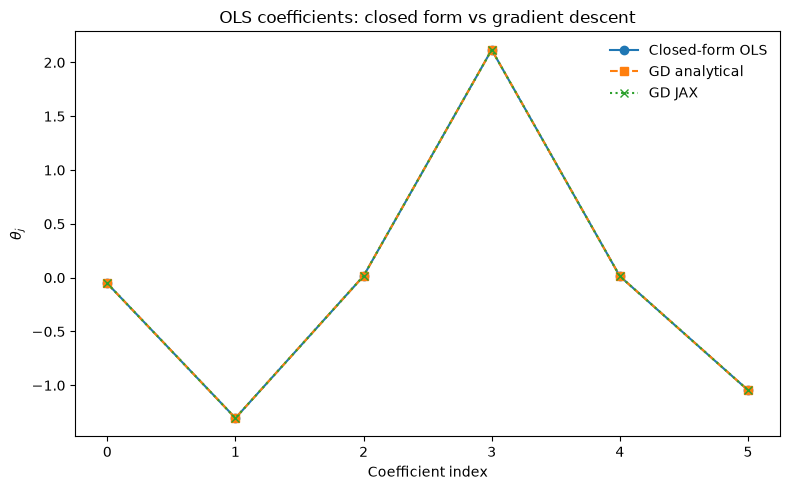

In [109]:


j = np.arange(len(theta_ols_closed))

plt.figure(figsize=(8, 5))

plt.plot(
    j,
    theta_ols_closed,
    "o-",
    label="Closed-form OLS"
)

plt.plot(
    j,
    theta_gd_analytic,
    "s--",
    label="GD analytical"
)

plt.plot(
    j,
    theta_gd_ad,
    "x:",
    label="GD JAX"
)

plt.xlabel("Coefficient index")
plt.ylabel(r"$\theta_j$")
plt.title("OLS coefficients: closed form vs gradient descent")

plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("../results/e3_gd_coefficients.pdf", bbox_inches="tight")
plt.show()

In [110]:

y_train_pred_closed = (
    X_train_e @ theta_ols_closed
    + y_mean_e
)

y_test_pred_closed = (
    X_test_e @ theta_ols_closed
    + y_mean_e
)

y_train_pred_gd = (
    X_train_e @ theta_gd_analytic
    + y_mean_e
)

y_test_pred_gd = (
    X_test_e @ theta_gd_analytic
    + y_mean_e
)

## e.4 The learning rate and the largest Hessian eigenvalue

## e.5 Gradient descent for Ridge

---
# Part f) Momentum, AdaGrad, RMSprop and Adam

---
# Part g) Lasso regression

## g.1 The subgradient of $|\theta|$ at zero

## g.2 Lasso by gradient descent

## g.3 Benchmark against scikit-learn

## g.4 Sparsity: Lasso against Ridge

---
# Part h) Stochastic gradient descent

## h.1 Mini-batches and epochs

## h.2 Dependence on batch size and number of epochs

## h.3 Learning rate schedule

## h.4 SGD against full-batch gradient descent

---
# Part i) Final comparison: OLS, Ridge and Lasso with cross-validation